<a href="https://colab.research.google.com/github/Rodrigoldarocha/Mapa-de-Reincidencia-STD/blob/main/Mapa_de_reincidencia_STD_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗺️ Mapa de Reincidência — Análise Preventiva de Chamados de Manutenção

> **Objetivo:** Identificar padrões de reincidência em chamados de manutenção por Local e Tipo de Serviço,  
> analisar o texto das notas iniciais para detectar linguagem de recorrência,  
> calcular um Score de criticidade composto e exportar base Excel formatada para gestão.

---

### 📋 Fluxo do notebook
| Etapa | Descrição |
|-------|-----------|
| 1 | Importar bibliotecas |
| 2 | Parâmetros globais |
| 3 | Carregar base |
| 4 | Pré-processamento |
| 5 | Lógica de reincidência temporal |
| 6 | Análise de texto (NLP) das Notas Iniciais |
| 7 | Tabela resumo |
| 8 | Score de criticidade composto |
| 9 | Visualizações |
| 10 | Exportar Excel formatado |
| 11 | Testes de validação |


## 🔹 1. Importar bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import unicodedata
import re
import warnings
from collections import Counter
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Suprimir avisos não críticos de forma centralizada
warnings.filterwarnings('ignore')

# Estilo padrão para gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Bibliotecas carregadas')


✅ Bibliotecas carregadas


## 🔹 2. Parâmetros globais

> Centralize aqui tudo que pode ser ajustado sem mexer no restante do código.


In [ ]:
# ⚙️ Parâmetros — edite aqui conforme necessário

ARQUIVO_ENTRADA     = 'PreventivasFornecedor.csv'   # caminho do CSV de entrada
ARQUIVO_SAIDA_EXCEL = 'resultado_reincidencia.xlsx'  # arquivo de saída

JANELA_REINCIDENCIA = 90    # dias para considerar reincidência temporal
NOTA_PADRAO         = 7     # nota usada quando campo está vazio (neutro)
TOP_N               = 15    # quantidade de itens nos gráficos de ranking

# Palavras que indicam que o problema já ocorreu antes (reincidência textual)
PALAVRAS_REINCIDENCIA = [
    'voltou', 'volta', 'novamente', 'reincidiu', 'reincidência',
    'mesmo problema', 'já foi', 'ja foi', 'não resolveu', 'nao resolveu',
    'retornou', 'retorno', 'persistindo', 'persiste', 'continua',
    'ainda', 'de novo', 'repetiu', 'não solucionado', 'nao solucionado',
    'origem', 'os de origem', 'chamado anterior', 'sem solução', 'sem solucao',
    'problema volta', 'já aberto', 'ja aberto', 'descaso', 'insistindo'
]

# Stop words para análise de frequência de termos
STOP_WORDS = {
    'a','o','e','de','do','da','dos','das','em','no','na','nos','nas',
    'um','uma','uns','umas','para','por','com','que','se','ao','aos',
    'as','os','mais','mas','ou','também','muito','bem','já','quando',
    'como','este','esta','isso','isto','seu','sua','seus','suas',
    'foi','ser','ter','está','esta','estão','tem','há','ha','não','nao',
    'nota','inicial','pois','porem','porém','favor','solicito','solicitar',
    'prezados','conforme','devido','sendo','pelo','pela','pelos','pelas',
    'todo','toda','todos','todas','qual','sobre','local','loja','unidade'
}

print('✅ Parâmetros configurados')


✅ Parâmetros configurados


## 🔹 3. Carregar base

In [ ]:
# Colab: descomente as duas linhas abaixo para fazer upload manual
# from google.colab import files
# files.upload()

# CORREÇÃO: Adicionado try/except para fornecer mensagem de erro clara
# se o arquivo não for encontrado, em vez de uma traceback genérica.
try:
    df = pd.read_csv(ARQUIVO_ENTRADA, sep=';', encoding='latin1')
    print(f'✅ Arquivo carregado com sucesso')
    print(f'Shape: {df.shape}')
    print(f'Colunas: {list(df.columns)}')
    display(df.head(3))
except FileNotFoundError:
    raise FileNotFoundError(
        f"Arquivo '{ARQUIVO_ENTRADA}' não encontrado.\n"
        "Verifique o caminho em ARQUIVO_ENTRADA (Célula de Parâmetros)."
    )


✅ Arquivo carregado com sucesso
Shape: (11054, 32)
Colunas: ['Numero_Chamado', 'No_Outro_Canal', 'Prioridade', 'Status', 'Solicitante', 'Data_Criacao', 'prazo_inicio', 'Data_Previsao_Conclusao', 'Data_Chegada', 'Data_Previsao_Chegada', 'Data_Conclusao', 'prazo_conclusao', 'Data_de_Fechamento', 'Fila', 'Grupo', 'Tipo', 'SubTipo', 'Valor_Total', 'Negocio', 'Local_Nome', 'Uniorg_Comercial', 'UF', 'Tempo_de_Custo', 'Fornecedor', 'originador', 'Anexo', 'regional', 'rede', 'modulo', 'Nota_Inicial', 'Data_Estimada_Tecnico', 'Substatus']


,Numero_Chamado,No_Outro_Canal,Prioridade,Status,Solicitante,Data_Criacao,prazo_inicio,Data_Previsao_Conclusao,Data_Chegada,Data_Previsao_Chegada,...,Tempo_de_Custo,Fornecedor,originador,Anexo,regional,rede,modulo,Nota_Inicial,Data_Estimada_Tecnico,Substatus
0,4748525,NaN,NaN,enfileirado,Emanuele Pinho Santos,13/04/2026 17:37,FP,04/05/2026 13:00,NaN,15/04/2026 11:00,...,Despesa,AVANÇO CONSTRUÇÕES E SERVIÇOS LTDA,t830892@toolsds.com,Nao,TERRI SPI NORDESTE,REDE - SP INTERIOR,NaN,Nota inicial: Tem 5 lâmpadas queimadas.,NaN,Aguardando Atendimento
1,4739929,NaN,NaN,aberto,Emanuele Pinho Santos,11/03/2026 14:32,NP,31/03/2026 10:31,12/03/2026 16:00,12/03/2026 16:31,...,Despesa,AVANÇO CONSTRUÇÕES E SERVIÇOS LTDA,t830892@toolsds.com,Sim,TERRI SPI NORDESTE,REDE - SP INTERIOR,NaN,Nota inicial: LAMPADA DO ESPAÇO AVNAÇAR QUEIMA...,NaN,Atendimento Realizado
2,4738279,189965.0,NaN,enfileirado,Abertura APP,04/03/2026 11:21,NP,20/03/2026 15:21,05/03/2026 12:15,05/03/2026 13:21,...,Despesa,AVANÇO CONSTRUÇÕES E SERVIÇOS LTDA,abertura.app,Sim,TERRI RS,REDE - SUL,Manutenção e Serviços de Rede,Nota Inicial: prezados devido as fortes chuvas...,17/04/2026 17:00,Avaliação Segundo Nível


## 🔹 4. Pré-processamento

In [ ]:
# --- Datas ---
df['Data_Criacao'] = pd.to_datetime(df['Data_Criacao'], dayfirst=True, errors='coerce')

# CORREÇÃO: Reportar linhas descartadas antes de removê-las,
# para rastreabilidade e auditoria do processo de limpeza.
antes = len(df)
df = df.dropna(subset=['Local_Nome', 'Tipo', 'Data_Criacao'])
descartados = antes - len(df)
if descartados > 0:
    print(f'⚠️  {descartados} linha(s) descartadas por campos essenciais nulos '
          f'(Local_Nome, Tipo ou Data_Criacao).')

# --- Valor_Total: vírgula → ponto ---
df['Valor_Total'] = (
    df['Valor_Total']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# --- Nota_Inicial: texto livre preservado; extração numérica separada ---
# Preservar o texto original para análise NLP
df['Descricao_Nota'] = df['Nota_Inicial'].astype(str).str.strip()

# Tentar extrair nota numérica se existir campo separado (caso contrário fica NaN → neutro)
df['Nota_Num'] = pd.to_numeric(df['Nota_Inicial'], errors='coerce')

# --- Ordenar ---
df = df.sort_values(by=['Local_Nome', 'Tipo', 'Data_Criacao']).reset_index(drop=True)

print(f'✅ Registros após limpeza: {len(df)}')
print(f'   Locais únicos: {df["Local_Nome"].nunique()}')
print(f'   Tipos únicos:  {df["Tipo"].nunique()}')
display(df[['Local_Nome', 'Tipo', 'Data_Criacao', 'Descricao_Nota']].head(10))


✅ Registros após limpeza: 11054
   Locais únicos: 623
   Tipos únicos:  47


,Local_Nome,Tipo,Data_Criacao,Descricao_Nota
0,ABAETETUBA-PA,Ar Condicionado,2026-03-24 16:52:00,Nota inicial: avaliar ac
1,ABAETETUBA-PA,Ar Condicionado,2026-04-08 12:04:00,Nota inicial: Verificar AC
2,ABAETETUBA-PA,Ar condicionado - Gerencia,2025-03-05 08:54:00,Nota Inicial: Ar não está ligando
3,ABAETETUBA-PA,Ar condicionado - Gerencia,2025-09-12 08:34:00,Nota Inicial: ar condicionado da agência não e...
4,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-06-18 09:16:00,Nota Inicial: O ar condicionado está desligand...
5,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-08-04 08:52:00,Nota Inicial: o equipamento está desligando so...
6,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-08-29 08:38:00,Nota Inicial: já realizamos abertura de 02 cha...
7,ABAETETUBA-PA,Ar condicionado - Sala técnica,2026-04-14 09:25:00,"Nota Inicial: ar não está gelando , problema n..."
8,ABAETETUBA-PA,CVE - Luminoso,2026-03-09 15:00:00,Nota Inicial: solicitamos manutenção em decorr...
9,ABAETETUBA-PA,Civil - Predial,2025-02-25 11:51:00,"Nota inicial: VISTORIA DE CALHAS, TELHADOS E R..."


## 🔹 5. Lógica de reincidência temporal

> Compara chamados consecutivos do mesmo Local + Tipo dentro da janela de dias definida.


In [ ]:
# Diferença em dias entre chamados consecutivos do mesmo local+tipo
df['diff_dias'] = (
    df.groupby(['Local_Nome', 'Tipo'])['Data_Criacao']
    .diff()
    .dt.days
)

# Reincidente temporal: mesmo local+tipo dentro da janela configurada
df['reincidente_temporal'] = (df['diff_dias'] <= JANELA_REINCIDENCIA).astype(int)

# Alias para retrocompatibilidade com células anteriores
df['reincidente'] = df['reincidente_temporal']

# diff_dias seguro para exportação Excel (NaT → -1 indica primeiro chamado do grupo)
df['diff_dias_export'] = df['diff_dias'].fillna(-1)

taxa_geral = df['reincidente'].mean()
print(f'Taxa geral de reincidência temporal: {taxa_geral:.1%}')
display(df[['Local_Nome', 'Tipo', 'Data_Criacao', 'diff_dias', 'reincidente']].head(20))


Taxa geral de reincidência temporal: 49.0%


,Local_Nome,Tipo,Data_Criacao,diff_dias,reincidente
0,ABAETETUBA-PA,Ar Condicionado,2026-03-24 16:52:00,NaN,0
1,ABAETETUBA-PA,Ar Condicionado,2026-04-08 12:04:00,14.0,1
2,ABAETETUBA-PA,Ar condicionado - Gerencia,2025-03-05 08:54:00,NaN,0
3,ABAETETUBA-PA,Ar condicionado - Gerencia,2025-09-12 08:34:00,190.0,0
4,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-06-18 09:16:00,NaN,0
5,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-08-04 08:52:00,46.0,1
6,ABAETETUBA-PA,Ar condicionado - Sala técnica,2025-08-29 08:38:00,24.0,1
7,ABAETETUBA-PA,Ar condicionado - Sala técnica,2026-04-14 09:25:00,228.0,0
8,ABAETETUBA-PA,CVE - Luminoso,2026-03-09 15:00:00,NaN,0
9,ABAETETUBA-PA,Civil - Predial,2025-02-25 11:51:00,NaN,0


## 🔹 6. Análise de Texto das Notas Iniciais 📝

> A coluna `Nota_Inicial` contém descrições em texto livre dos problemas reportados.  
> Aqui extraímos sinais linguísticos de reincidência, frequência de termos e correlação com a taxa de reincidência temporal.


In [ ]:
# ── Funções de NLP leve ─────────────────────────────────────────────────────

def normalizar(texto: str) -> str:
    """Remove acentos, caixa alta e prefixo 'Nota inicial:'."""
    if pd.isna(texto) or str(texto).strip() in ('nan', ''):
        return ''
    texto = str(texto).lower()
    # Remove prefixo padrão
    texto = re.sub(r'^nota\s*inicial\s*[:.-]*\s*', '', texto)
    # Remove acentos via decomposição Unicode
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    # Mantém apenas alfanuméricos e espaços
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def detectar_reincidencia_textual(texto_norm: str,
                                   palavras: list = PALAVRAS_REINCIDENCIA) -> int:
    """Retorna 1 se o texto contém linguagem que indica problema recorrente."""
    if not texto_norm:
        return 0
    # Normalizar palavras-chave da lista para garantir comparação homogênea
    palavras_norm = [normalizar(p) for p in palavras]
    return int(any(p in texto_norm for p in palavras_norm))


def palavras_relevantes(texto_norm: str,
                         stop_words: set = STOP_WORDS) -> list:
    """Retorna lista de tokens relevantes (sem stop words, >= 3 chars)."""
    if not texto_norm:
        return []
    return [w for w in texto_norm.split() if w not in stop_words and len(w) >= 3]


# ── Aplicar ao dataframe ─────────────────────────────────────────────────────
df['nota_norm']           = df['Descricao_Nota'].apply(normalizar)
df['reincidente_textual'] = df['nota_norm'].apply(detectar_reincidencia_textual)
df['palavras_chave']      = df['nota_norm'].apply(palavras_relevantes)

# Flag combinada: reincidente por tempo OU por texto
df['reincidente_combinado'] = (
    (df['reincidente_temporal'] == 1) | (df['reincidente_textual'] == 1)
).astype(int)

print(f'Chamados com linguagem de reincidência no texto: '
      f'{df["reincidente_textual"].sum()} ({df["reincidente_textual"].mean():.1%})')
print(f'Reincidência combinada (temporal + textual):     '
      f'{df["reincidente_combinado"].sum()} ({df["reincidente_combinado"].mean():.1%})')

# Exemplos de notas detectadas
exemplos = df[df['reincidente_textual'] == 1][['Local_Nome', 'Tipo', 'Descricao_Nota']].head(5)
print('\nExemplos de notas com linguagem de recorrência:')
display(exemplos)


Chamados com linguagem de reincidência no texto: 687 (6.2%)
Reincidência combinada (temporal + textual):     5738 (51.9%)

Exemplos de notas com linguagem de recorrência:


,Local_Nome,Tipo,Descricao_Nota
19,ABAETETUBA-PA,Vandalismo,"Nota inicial: Vidro do corrimão quebrado , sol..."
25,ACAILANDIA-MA,Ar condicionado - Tesouraria,Nota Inicial: ar condicionado não está resfria...
137,ALEIXO-CAP-AM,Vandalismo,Nota inicial: Furto do difusor do ar-condicio...
145,ALMIRANTE BARROSO-BELEM-PA II,Elétrica,Nota Inicial: voltagem da tomada da Impressour...
165,ALPHAVILLE-SALVADOR-BA,Elétrica,Nota Inicial: auto atendimento e luminoso apa...


In [ ]:
# ── Frequência de termos por Tipo de Serviço ────────────────────────────────

def top_termos_por_grupo(df: pd.DataFrame,
                          coluna_grupo: str,
                          col_palavras: str = 'palavras_chave',
                          top: int = 10) -> pd.DataFrame:
    """Retorna DataFrame com os termos mais frequentes por grupo."""
    resultado = []
    for grupo, sub in df.groupby(coluna_grupo):
        todas = [p for lista in sub[col_palavras] for p in lista]
        for termo, freq in Counter(todas).most_common(top):
            resultado.append({'Grupo': grupo, 'Termo': termo, 'Frequencia': freq})
    return pd.DataFrame(resultado)

termos_tipo  = top_termos_por_grupo(df, 'Tipo', top=8)
termos_local = top_termos_por_grupo(df, 'Local_Nome', top=8)

print('Top termos por Tipo de Serviço:')
display(termos_tipo.head(20))


Top termos por Tipo de Serviço:


,Grupo,Termo,Frequencia
0,Acessórios de Ergonomia,descricao,6
1,Acessórios de Ergonomia,andar,4
2,Acessórios de Ergonomia,terreo,4
3,Acessórios de Ergonomia,bairro,4
4,Acessórios de Ergonomia,boa,4
5,Acessórios de Ergonomia,viagem,4
6,Acessórios de Ergonomia,estacao,4
7,Acessórios de Ergonomia,empresas,3
8,Alarmes,sirene,1
9,Alarmes,disparada,1


In [ ]:
# ── Correlação: linguagem de recorrência × reincidência temporal ─────────────

correlacao = df.groupby('reincidente_textual').agg(
    Qtd_Chamados      = ('Numero_Chamado', 'count'),
    Taxa_Reincid_Temp = ('reincidente_temporal', 'mean'),
    Custo_Medio       = ('Valor_Total', 'mean')
).reset_index()

correlacao['reincidente_textual'] = correlacao['reincidente_textual'].map({
    0: 'Sem linguagem de recorrência',
    1: 'Com linguagem de recorrência'
})
correlacao['Taxa_Reincid_Temp'] = correlacao['Taxa_Reincid_Temp'].map('{:.1%}'.format)
correlacao['Custo_Medio']       = correlacao['Custo_Medio'].map('R$ {:.2f}'.format)

print('Correlação entre linguagem do texto e reincidência temporal:')
display(correlacao)


Correlação entre linguagem do texto e reincidência temporal:


,reincidente_textual,Qtd_Chamados,Taxa_Reincid_Temp,Custo_Medio
0,Sem linguagem de recorrência,10367,48.7%,R$ 748.70
1,Com linguagem de recorrência,687,52.4%,R$ 2534.72


In [ ]:
# ── Resumo de reincidência textual por Local ─────────────────────────────────

resumo_texto_local = df.groupby('Local_Nome').agg(
    Total_Chamados       = ('Numero_Chamado', 'count'),
    Reincid_Textual      = ('reincidente_textual', 'sum'),
    Tx_Reincid_Textual   = ('reincidente_textual', 'mean'),
    Reincid_Temporal     = ('reincidente_temporal', 'sum'),
    Tx_Reincid_Temporal  = ('reincidente_temporal', 'mean'),
    Reincid_Combinada    = ('reincidente_combinado', 'sum'),
    Tx_Reincid_Combinada = ('reincidente_combinado', 'mean'),
).reset_index().sort_values('Tx_Reincid_Combinada', ascending=False)

print('Locais com maior reincidência combinada (Top 10):')
display(resumo_texto_local.head(10))


Locais com maior reincidência combinada (Top 10):


,Local_Nome,Total_Chamados,Reincid_Textual,Tx_Reincid_Textual,Reincid_Temporal,Tx_Reincid_Temporal,Reincid_Combinada,Tx_Reincid_Combinada
567,SELECT ASA NORTE,1,1,1.000000,0,0.000000,1,1.000000
526,PLAT MID ES,1,1,1.000000,0,0.000000,1,1.000000
457,PA URB-MACEIO-RUA DO SOL III,3,1,0.333333,2,0.666667,3,1.000000
522,PLAT MID ALAGOAS,1,1,1.000000,0,0.000000,1,1.000000
156,LOJA EXCLUSIVA DASS VITORIA CONQ BA,1,1,1.000000,0,0.000000,1,1.000000
298,NUCLEO PROSPERA BATURITE,1,1,1.000000,0,0.000000,1,1.000000
166,LOJA EXCLUSIVA HEINEKEN BENEVIDES-PA,1,1,1.000000,0,0.000000,1,1.000000
313,NUCLEO PROSPERA PATOS,2,2,1.000000,1,0.500000,2,1.000000
202,LOJA EXCLUSIVA SAUDE SALVADOR,1,1,1.000000,0,0.000000,1,1.000000
564,SEDE RECIFE,213,4,0.018779,195,0.915493,196,0.920188


## 🔹 7. Tabela resumo por Local × Tipo

In [ ]:
resumo = df.groupby(['Local_Nome', 'Tipo']).agg(
    Total_Chamados    = ('Numero_Chamado', 'count'),
    Reincidencias     = ('reincidente_temporal', 'sum'),
    Reincid_Textual   = ('reincidente_textual', 'sum'),
    Reincid_Combinada = ('reincidente_combinado', 'sum'),
    Custo_Total       = ('Valor_Total', 'sum'),
    Nota_Media        = ('Nota_Num', 'mean')
).reset_index()

resumo.columns = [
    'Local', 'Tipo', 'Total_Chamados',
    'Reincidencias', 'Reincid_Textual', 'Reincid_Combinada',
    'Custo_Total', 'Nota_Media'
]

# Taxas — divisão segura (evita ZeroDivisionError com replace(0, np.nan))
resumo['Tx_Reincidencia']      = resumo['Reincidencias']     / resumo['Total_Chamados'].replace(0, np.nan)
resumo['Tx_Reincid_Textual']   = resumo['Reincid_Textual']   / resumo['Total_Chamados'].replace(0, np.nan)
resumo['Tx_Reincid_Combinada'] = resumo['Reincid_Combinada'] / resumo['Total_Chamados'].replace(0, np.nan)

# Nota ausente → valor neutro configurado em parâmetros
resumo['Nota_Media'] = resumo['Nota_Media'].fillna(NOTA_PADRAO)

display(resumo.head(10))


,Local,Tipo,Total_Chamados,Reincidencias,Reincid_Textual,Reincid_Combinada,Custo_Total,Nota_Media,Tx_Reincidencia,Tx_Reincid_Textual,Tx_Reincid_Combinada
0,ABAETETUBA-PA,Ar Condicionado,2,1,0,1,2042.10,7.0,0.500000,0.000000,0.500000
1,ABAETETUBA-PA,Ar condicionado - Gerencia,2,0,0,0,1320.74,7.0,0.000000,0.000000,0.000000
2,ABAETETUBA-PA,Ar condicionado - Sala técnica,4,2,0,2,0.00,7.0,0.500000,0.000000,0.500000
3,ABAETETUBA-PA,CVE - Luminoso,1,0,0,0,456.55,7.0,0.000000,0.000000,0.000000
4,ABAETETUBA-PA,Civil - Predial,2,0,0,0,0.00,7.0,0.000000,0.000000,0.000000
5,ABAETETUBA-PA,Elétrica,4,2,0,2,0.00,7.0,0.500000,0.000000,0.500000
6,ABAETETUBA-PA,No Break,2,0,0,0,0.00,7.0,0.000000,0.000000,0.000000
7,ABAETETUBA-PA,Pórtico,1,0,0,0,2801.09,7.0,0.000000,0.000000,0.000000
8,ABAETETUBA-PA,Vandalismo,3,2,1,2,5498.56,7.0,0.666667,0.333333,0.666667
9,ACAILANDIA-MA,Ar Condicionado,2,1,0,1,0.00,7.0,0.500000,0.000000,0.500000


## 🔹 8. Score de criticidade composto 🔥

> **Score Base** = Reincidências × (10 − Nota Média)  
> **Bônus Textual** = +20% se taxa de reincidência textual > 20%  
> **Score Avançado** = Score Base × (1 + Custo / Custo Máximo) × Bônus Textual


In [ ]:
# Score base
resumo['Score'] = resumo['Reincidencias'] * (10 - resumo['Nota_Media'])

# Bônus textual: locais com linguagem de recorrência elevada (+20%)
resumo['Bonus_Textual'] = resumo['Tx_Reincid_Textual'].apply(
    lambda x: 1.20 if x > 0.20 else 1.0
)

# Score avançado: incorpora custo normalizado e bônus textual
custo_max = resumo['Custo_Total'].max()
if pd.isna(custo_max) or custo_max == 0:
    resumo['Score_Avancado'] = resumo['Score'] * resumo['Bonus_Textual']
else:
    resumo['Score_Avancado'] = (
        resumo['Score']
        * (1 + resumo['Custo_Total'].fillna(0) / custo_max)
        * resumo['Bonus_Textual']
    )

# Classificação de criticidade baseada no Score Base
resumo['Criticidade'] = pd.cut(
    resumo['Score'],
    bins=[-1, 0, 5, 15, float('inf')],
    labels=['Sem Reincidência', 'Baixa', 'Média', 'Alta']
)

resumo = resumo.sort_values('Score_Avancado', ascending=False).reset_index(drop=True)

print('Distribuição de criticidade:')
print(resumo['Criticidade'].value_counts())
print(f'\nLocais com bônus textual aplicado: {(resumo["Bonus_Textual"] > 1).sum()}')
display(resumo.head(20))


Distribuição de criticidade:
Criticidade
Sem Reincidência    2350
Baixa                772
Média                715
Alta                 244
Name: count, dtype: int64

Locais com bônus textual aplicado: 370


,Local,Tipo,Total_Chamados,Reincidencias,Reincid_Textual,Reincid_Combinada,Custo_Total,Nota_Media,Tx_Reincidencia,Tx_Reincid_Textual,Tx_Reincid_Combinada,Score,Bonus_Textual,Score_Avancado,Criticidade
0,SEDE RECIFE,Civil,96,95,2,95,73396.56,7.0,0.989583,0.020833,0.989583,285.0,1.0,500.305442,Alta
1,CENTRO-RIO BRANCO-AC,Hidro-Sanitária,43,42,3,42,62528.40,7.0,0.976744,0.069767,0.976744,126.0,1.0,207.092801,Alta
2,SEDE RECIFE,Hidráulica,46,44,0,44,51385.27,7.0,0.956522,0.000000,0.956522,132.0,1.0,201.814722,Alta
3,SEDE SALVADOR,Civil,35,34,1,34,83095.24,7.0,0.971429,0.028571,0.971429,102.0,1.0,189.239016,Alta
4,LOJA SELECT AGAMENON-RECIFE,Civil - Predial,27,26,1,26,36350.44,7.0,0.962963,0.037037,0.962963,78.0,1.0,107.183590,Alta
5,RECIFE-BOA VIAGEM,Civil,24,23,3,23,53379.81,7.0,0.958333,0.125000,0.958333,69.0,1.0,106.910591,Alta
6,SEDE RECIFE,Elétrica,29,28,1,28,15564.54,7.0,0.965517,0.034483,0.965517,84.0,1.0,97.457055,Alta
7,BELEM-NAZARE,Civil - Predial,25,23,5,24,19832.71,7.0,0.920000,0.200000,0.960000,69.0,1.0,83.085284,Alta
8,SEDE SALVADOR,Elétrica,25,24,0,24,13641.50,7.0,0.960000,0.000000,0.960000,72.0,1.0,82.109486,Alta
9,MANAUS-AV EDUARDO RIBEIRO,Elétrica,24,22,0,22,16000.90,7.0,0.916667,0.000000,0.916667,66.0,1.0,76.869831,Alta


## 🔹 9. Visualizações 📊

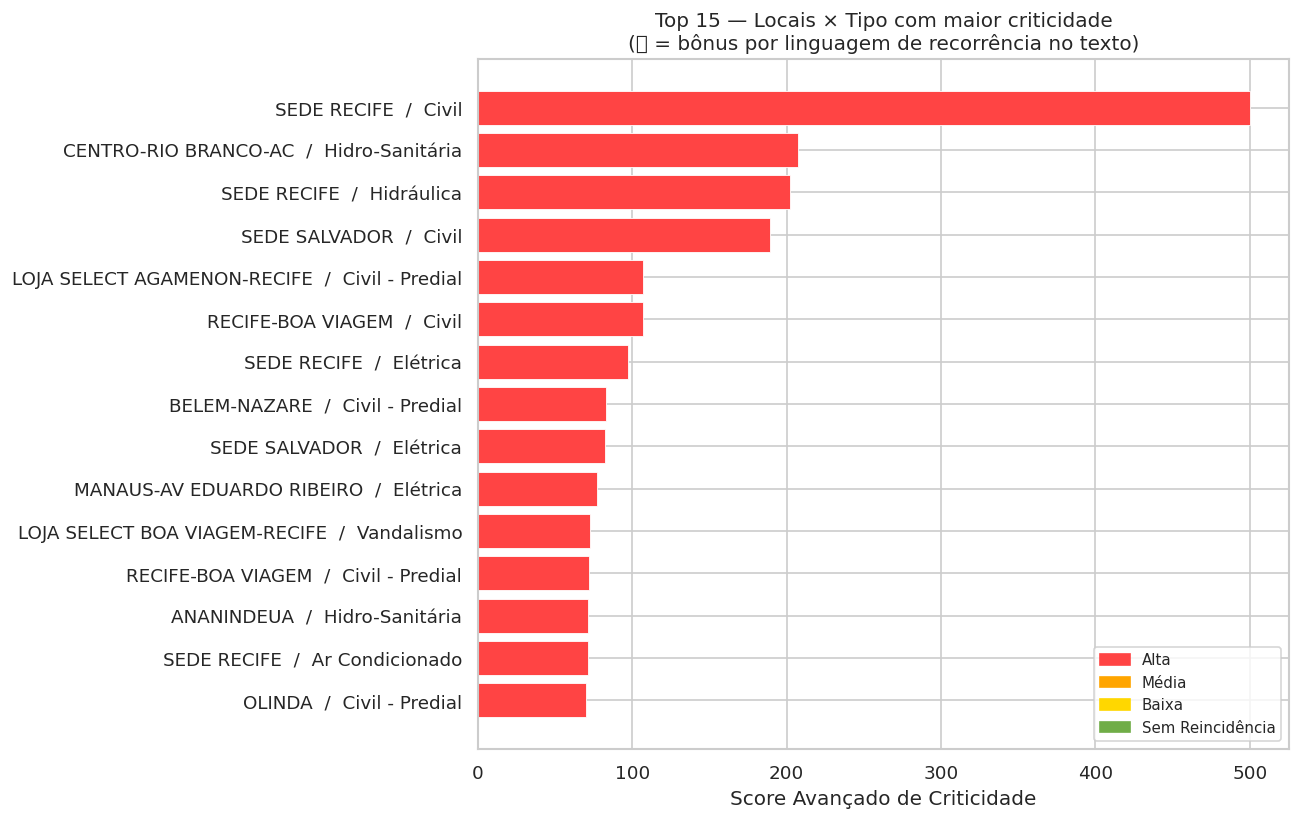

In [ ]:
# ── Gráfico 1: Top N — Score por Local × Tipo ────────────────────────────────
top = resumo.head(TOP_N).copy()

cores = top['Criticidade'].fillna('Sem Reincidência').astype(str).map({
    'Alta':             '#FF4444',
    'Média':            '#FFA500',
    'Baixa':            '#FFD700',
    'Sem Reincidência': '#70AD47'
}).fillna('#AAAAAA')

fig, ax = plt.subplots(figsize=(11, 7))
labels = top['Local'] + '  /  ' + top['Tipo']
ax.barh(labels, top['Score_Avancado'], color=cores, edgecolor='white', linewidth=0.5)

# Marcar itens com bônus textual
for i, (_, row) in enumerate(top.iterrows()):
    if row['Bonus_Textual'] > 1:
        ax.text(top['Score_Avancado'].max() * 0.02, i, '  📝', va='center', fontsize=9)

ax.set_xlabel('Score Avançado de Criticidade')
ax.set_title(
    f'Top {TOP_N} — Locais × Tipo com maior criticidade\n'
    '(📝 = bônus por linguagem de recorrência no texto)'
)
ax.invert_yaxis()

legenda = [
    mpatches.Patch(color='#FF4444', label='Alta'),
    mpatches.Patch(color='#FFA500', label='Média'),
    mpatches.Patch(color='#FFD700', label='Baixa'),
    mpatches.Patch(color='#70AD47', label='Sem Reincidência'),
]
ax.legend(handles=legenda, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


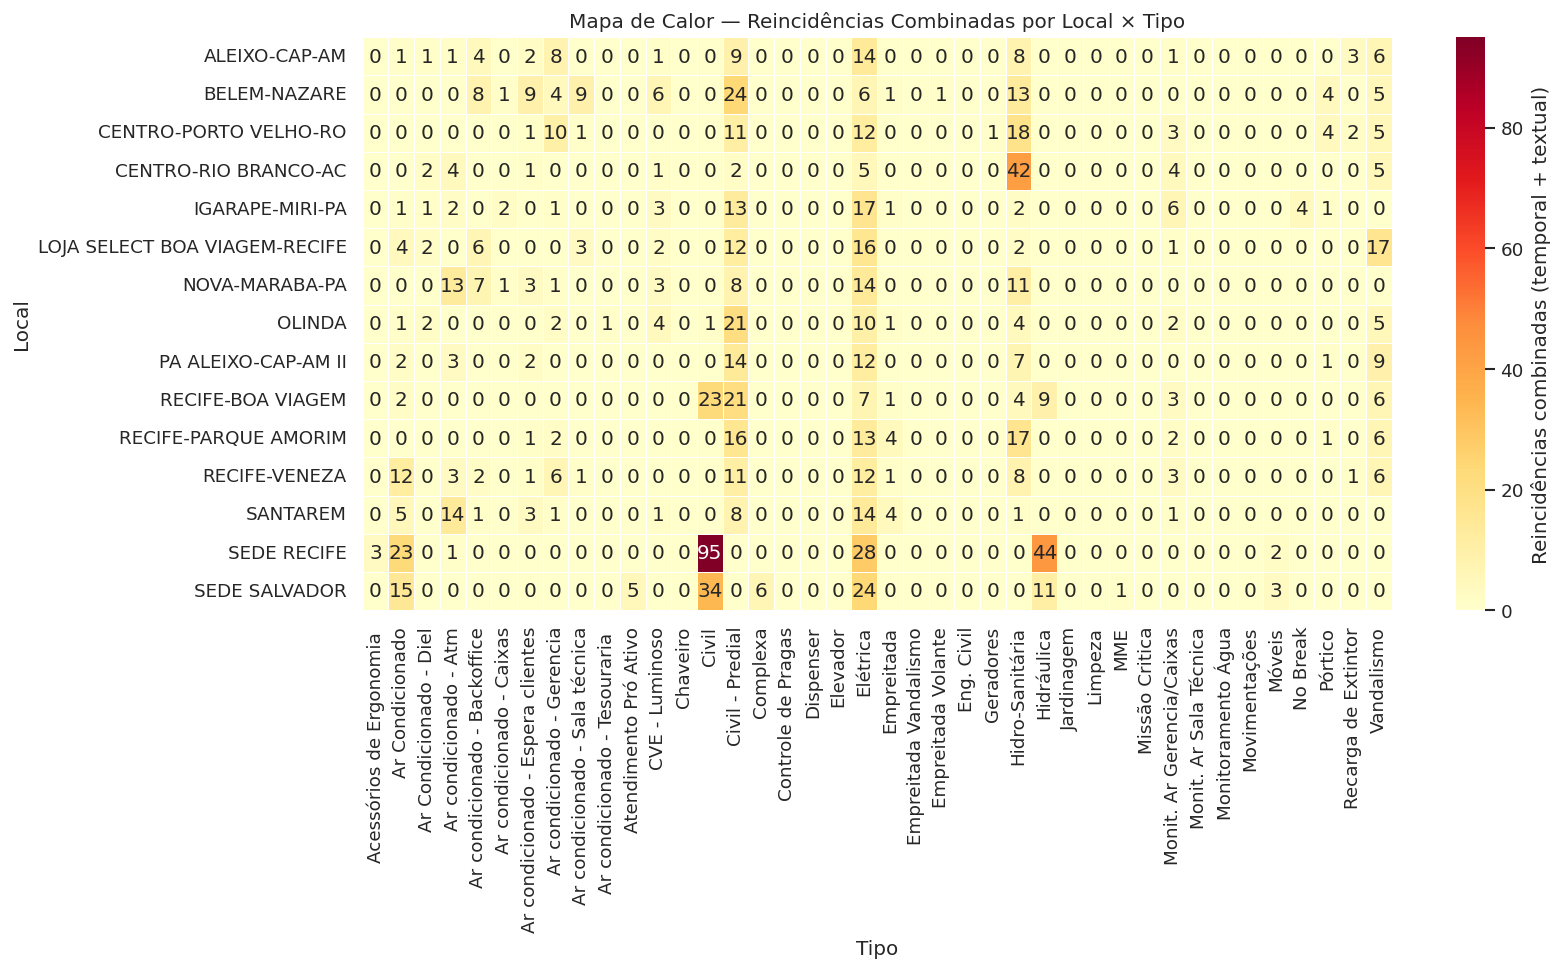

In [ ]:
# ── Gráfico 2: Mapa de Calor — Reincidências por Local × Tipo ────────────────
# CORREÇÃO: 'top_locais' estava indefinido no código original.
# Agora é derivado explicitamente do ranking de score.
top_locais = (
    resumo.groupby('Local')['Score_Avancado']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
    .tolist()
)

pivot = resumo[resumo['Local'].isin(top_locais)].pivot_table(
    index='Local', columns='Tipo',
    values='Reincid_Combinada', fill_value=0
)

n_rows = len(pivot)
fig_h = max(6, n_rows * 0.55)
plt.figure(figsize=(14, fig_h))
sns.heatmap(
    pivot, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5,
    cbar_kws={'label': 'Reincidências combinadas (temporal + textual)'}
)
plt.title('Mapa de Calor — Reincidências Combinadas por Local × Tipo')
plt.tight_layout()
plt.show()


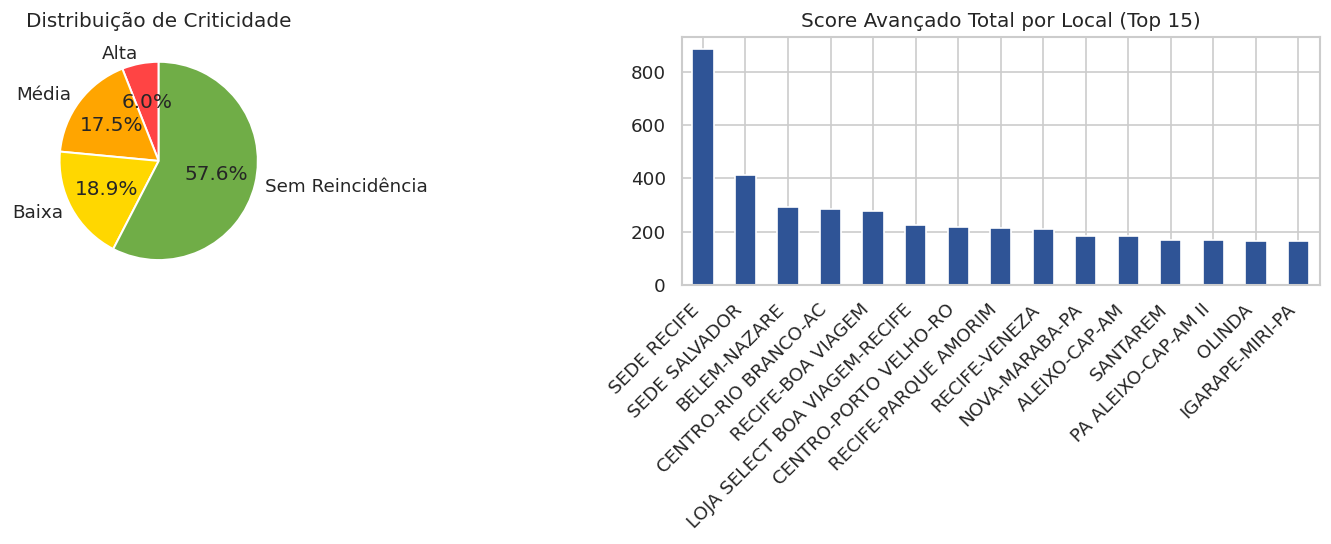

In [ ]:
# ── Gráfico 3: Distribuição de criticidade + Score total por local ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza com ordem de criticidade garantida
ordem_crit = ['Alta', 'Média', 'Baixa', 'Sem Reincidência']
crit_counts = resumo['Criticidade'].value_counts().reindex(ordem_crit, fill_value=0)
colors_pie = ['#FF4444', '#FFA500', '#FFD700', '#70AD47']
crit_counts.plot.pie(
    ax=axes[0], autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
axes[0].set_title('Distribuição de Criticidade')
axes[0].set_ylabel('')

# Barras de score por local
ranking_local = (
    resumo.groupby('Local')['Score_Avancado']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N)
)
ranking_local.plot.bar(ax=axes[1], color='#2F5496', edgecolor='white')
axes[1].set_title(f'Score Avançado Total por Local (Top {TOP_N})')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(pad=2.0)
plt.show()


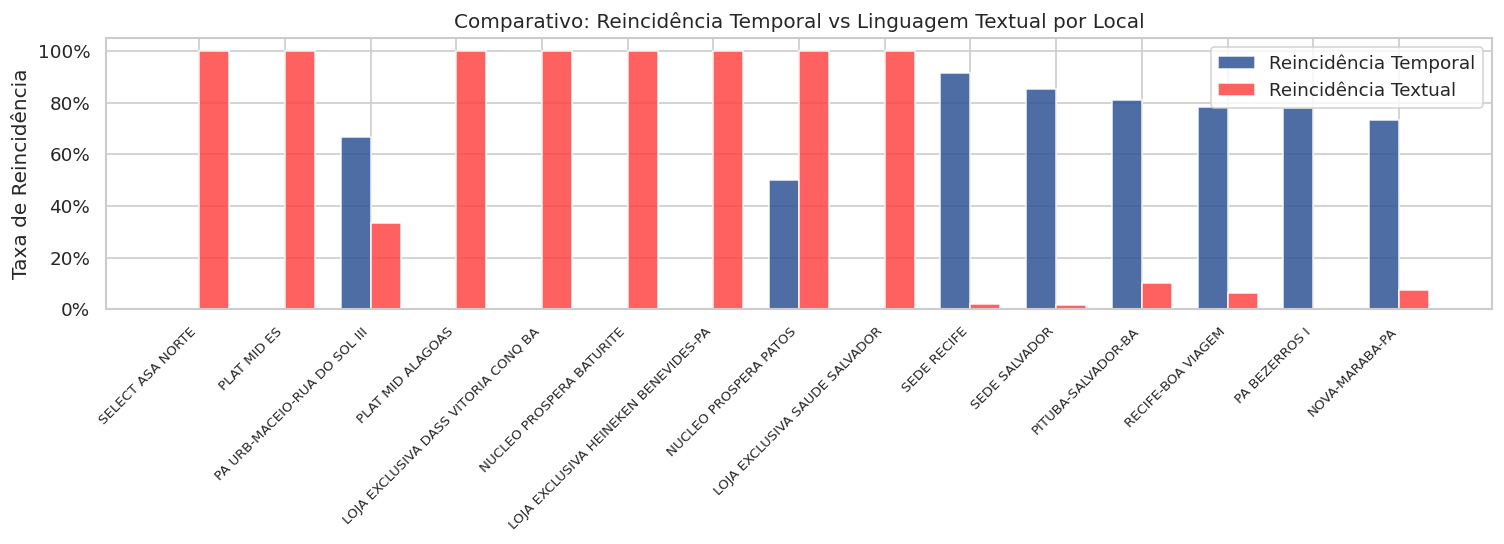

In [ ]:
# ── Gráfico 4: Comparativo reincidência temporal vs textual por local ─────────
top_local_texto = resumo_texto_local.head(min(TOP_N, len(resumo_texto_local))).copy()

x = range(len(top_local_texto))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width / 2 for i in x], top_local_texto['Tx_Reincid_Temporal'],
       width, label='Reincidência Temporal', color='#2F5496', alpha=0.85)
ax.bar([i + width / 2 for i in x], top_local_texto['Tx_Reincid_Textual'],
       width, label='Reincidência Textual', color='#FF4444', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(top_local_texto['Local_Nome'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Taxa de Reincidência')
ax.set_title('Comparativo: Reincidência Temporal vs Linguagem Textual por Local')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
plt.tight_layout(pad=2.0)
plt.show()


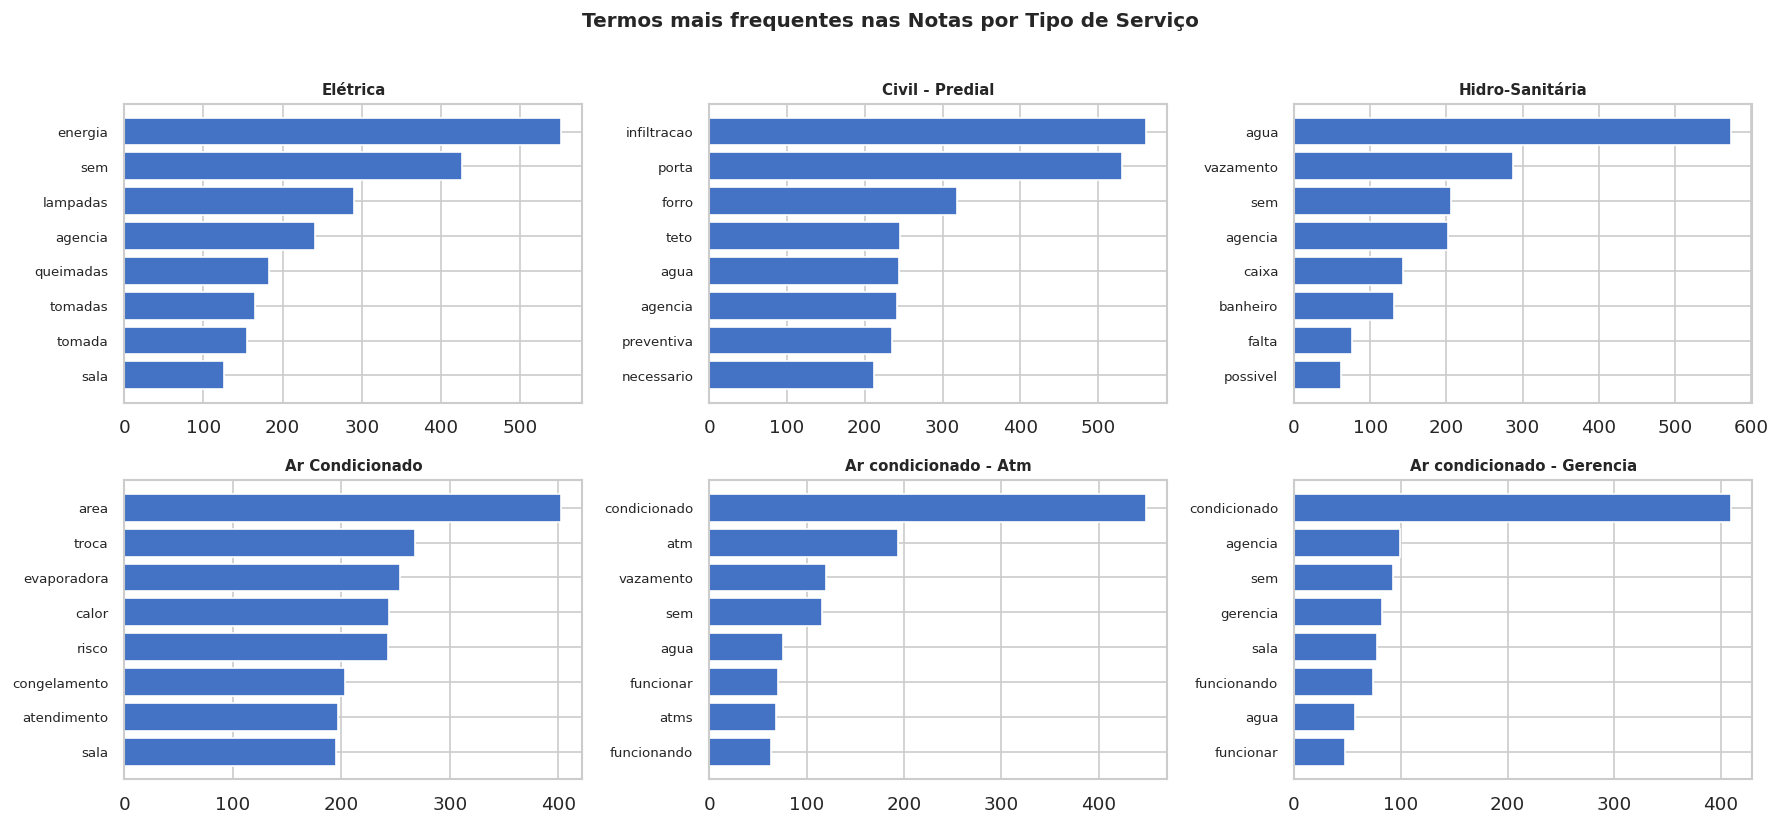

In [ ]:
# ── Gráfico 5: Top termos por Tipo de Serviço (grid de barras) ────────────────
tipos_plot = df['Tipo'].value_counts().head(6).index.tolist()
termos_plot = termos_tipo[termos_tipo['Grupo'].isin(tipos_plot)]

n_tipos = len(tipos_plot)
ncols = 3
nrows = (n_tipos + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, tipo in enumerate(tipos_plot):
    sub = termos_plot[termos_plot['Grupo'] == tipo].head(8)
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].barh(sub['Termo'], sub['Frequencia'], color='#4472C4', edgecolor='white')
    axes[i].set_title(tipo[:40], fontsize=9, fontweight='bold')
    axes[i].invert_yaxis()
    axes[i].tick_params(axis='y', labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Termos mais frequentes nas Notas por Tipo de Serviço', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 🔹 10. Exportar para Excel formatado 📊

> **5 abas:**  
> 1. Resumo Executivo — ranking por Local × Tipo com score composto  
> 2. Ranking por Local — consolidado por local  
> 3. Análise de Texto — reincidência textual e termos por local  
> 4. Termos por Tipo — frequência de palavras por tipo de serviço  
> 5. Dados Brutos — todos os chamados com flags calculadas


In [ ]:
# ── Funções auxiliares de formatação Excel ──────────────────────────────────

CRIT_COLORS = {
    'Alta':             'FF4444',
    'Média':            'FFA500',
    'Baixa':            'FFD700',
    'Sem Reincidência': '70AD47'
}


def aplicar_cabecalho(ws, linha: int, colunas: int, bg: str = '2F5496') -> None:
    """Aplica estilo de cabeçalho (negrito, cor de fundo, bordas) a uma linha."""
    for col in range(1, colunas + 1):
        cell = ws.cell(row=linha, column=col)
        cell.font      = Font(bold=True, color='FFFFFF', name='Arial', size=10)
        cell.fill      = PatternFill('solid', fgColor=bg)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border    = Border(
            left=Side(style='thin'), right=Side(style='thin'),
            top=Side(style='thin'),  bottom=Side(style='thin')
        )


def aplicar_titulo(ws, texto: str, n_colunas: int,
                   fg_color: str = '1F3864') -> None:
    """Mescla a primeira linha e aplica título estilizado."""
    ultima_col = get_column_letter(n_colunas)
    ws.merge_cells(f'A1:{ultima_col}1')
    ws['A1']           = texto
    ws['A1'].font      = Font(bold=True, color='FFFFFF', name='Arial', size=13)
    ws['A1'].fill      = PatternFill('solid', fgColor=fg_color)
    ws['A1'].alignment = Alignment(horizontal='center', vertical='center')
    ws.row_dimensions[1].height = 28


def ajustar_larguras(ws, larguras: list) -> None:
    """Define largura de cada coluna conforme lista fornecida."""
    for i, w in enumerate(larguras, 1):
        ws.column_dimensions[get_column_letter(i)].width = w


# CORREÇÃO: Todas as abas são escritas em UM ÚNICO ExcelWriter para evitar
# múltiplas aberturas/fechamentos do arquivo (que causavam corrupção em
# versões mais antigas do openpyxl e comportamento inconsistente).
with pd.ExcelWriter(ARQUIVO_SAIDA_EXCEL, engine='openpyxl') as writer:

    # ── Aba 1: Resumo Executivo ──────────────────────────────────────────────
    resumo_excel = resumo.copy()
    resumo_excel['Tx_Reincidencia']    = resumo_excel['Tx_Reincidencia'].fillna(0).round(2)
    resumo_excel['Tx_Reincid_Textual'] = resumo_excel['Tx_Reincid_Textual'].fillna(0).round(2)
    resumo_excel['Bonus_Textual']      = resumo_excel['Bonus_Textual'].apply(
        lambda x: '✅ +20%' if x > 1 else '-'
    )
    resumo_excel['Score']          = resumo_excel['Score'].round(2)
    resumo_excel['Score_Avancado'] = resumo_excel['Score_Avancado'].round(2)
    resumo_excel.to_excel(writer, sheet_name='Resumo Executivo', index=False, startrow=2)

    ws = writer.sheets['Resumo Executivo']
    aplicar_titulo(ws, '🔥 MAPA DE REINCIDÊNCIA — ANÁLISE PREVENTIVA DE FORNECEDORES',
                   n_colunas=14, fg_color='1F3864')
    aplicar_cabecalho(ws, linha=2, colunas=14)
    ws.row_dimensions[2].height = 30
    ajustar_larguras(ws, [4, 24, 20, 14, 16, 16, 17, 13, 13, 16, 10, 14, 13, 18])
    ws.freeze_panes = 'A3'

    # Colorir coluna de criticidade (col 14)
    for row_idx in range(3, ws.max_row + 1):
        crit = ws.cell(row=row_idx, column=14).value
        if crit in CRIT_COLORS:
            cor_texto = 'FFFFFF' if crit in ('Alta', 'Média') else '000000'
            ws.cell(row=row_idx, column=14).fill = PatternFill('solid', fgColor=CRIT_COLORS[crit])
            ws.cell(row=row_idx, column=14).font = Font(bold=True, color=cor_texto)

    # ── Aba 2: Ranking por Local ─────────────────────────────────────────────
    rl = resumo.groupby('Local').agg(
        Total_Chamados   = ('Total_Chamados', 'sum'),
        Reincid_Temporal = ('Reincidencias', 'sum'),
        Reincid_Textual  = ('Reincid_Textual', 'sum'),
        Reincid_Comb     = ('Reincid_Combinada', 'sum'),
        Score_Total      = ('Score_Avancado', 'sum')
    ).reset_index().sort_values('Score_Total', ascending=False).reset_index(drop=True)

    rl.index = rl.index + 1
    rl.insert(0, 'Pos.', rl.index)
    medals = {1: '🥇', 2: '🥈', 3: '🥉'}
    rl['Pos.'] = rl['Pos.'].apply(lambda x: medals.get(x, str(x)))
    rl.to_excel(writer, sheet_name='Ranking por Local', index=False, startrow=2)

    ws2 = writer.sheets['Ranking por Local']
    aplicar_titulo(ws2, '🏆 RANKING POR LOCAL', n_colunas=7, fg_color='1F3864')
    aplicar_cabecalho(ws2, linha=2, colunas=7)
    ajustar_larguras(ws2, [8, 28, 15, 17, 16, 18, 13])
    ws2.freeze_panes = 'A3'

    # ── Aba 3: Análise de Texto ──────────────────────────────────────────────
    rt = resumo_texto_local.sort_values(
        'Tx_Reincid_Combinada', ascending=False
    ).reset_index(drop=True).copy()

    # Guardar valores numéricos antes de formatar como string
    tx_comb_num = rt['Tx_Reincid_Combinada'].copy()

    rt['Tx_Reincid_Textual']   = rt['Tx_Reincid_Textual'].apply(lambda x: f'{x:.1%}')
    rt['Tx_Reincid_Temporal']  = rt['Tx_Reincid_Temporal'].apply(lambda x: f'{x:.1%}')
    rt['Tx_Reincid_Combinada'] = rt['Tx_Reincid_Combinada'].apply(lambda x: f'{x:.1%}')
    rt.to_excel(writer, sheet_name='Análise de Texto', index=False, startrow=2)

    ws3 = writer.sheets['Análise de Texto']
    aplicar_titulo(ws3, '📝 ANÁLISE DE LINGUAGEM POR LOCAL',
                   n_colunas=8, fg_color='375623')
    aplicar_cabecalho(ws3, linha=2, colunas=8, bg='375623')
    ajustar_larguras(ws3, [28, 15, 16, 13, 16, 13, 18, 13])
    ws3.freeze_panes = 'A3'

    # CORREÇÃO: Usar valores numéricos originais (antes da formatação em %)
    # para o condicional de destaque, eliminando a conversão frágil de string.
    for i, val in enumerate(tx_comb_num):
        if val > 0.50:
            excel_row_idx = i + 3
            cell = ws3.cell(row=excel_row_idx, column=8)
            cell.fill = PatternFill('solid', fgColor='FF4444')
            cell.font = Font(bold=True, color='FFFFFF')

    # ── Aba 4: Termos por Tipo ───────────────────────────────────────────────
    termos_tipo.to_excel(writer, sheet_name='Termos por Tipo', index=False, startrow=2)

    ws4 = writer.sheets['Termos por Tipo']
    aplicar_titulo(ws4, '🔑 TERMOS MAIS FREQUENTES POR TIPO DE SERVIÇO',
                   n_colunas=3, fg_color='7B3F00')
    aplicar_cabecalho(ws4, linha=2, colunas=3, bg='7B3F00')
    ajustar_larguras(ws4, [30, 20, 12])
    ws4.freeze_panes = 'A3'

    # ── Aba 5: Dados Brutos ──────────────────────────────────────────────────
    cols_export = [
        'Numero_Chamado', 'Local_Nome', 'Tipo', 'Data_Criacao',
        'Valor_Total', 'Descricao_Nota',
        'diff_dias_export', 'reincidente_temporal', 'reincidente_textual', 'reincidente_combinado'
    ]
    df_export = df[cols_export].copy()
    df_export['Data_Criacao'] = df_export['Data_Criacao'].dt.strftime('%d/%m/%Y %H:%M')
    df_export.to_excel(writer, sheet_name='Dados Brutos', index=False, startrow=2)

    ws5 = writer.sheets['Dados Brutos']
    aplicar_titulo(ws5, '📄 DADOS BRUTOS COM FLAGS DE REINCIDÊNCIA',
                   n_colunas=10, fg_color='404040')
    aplicar_cabecalho(ws5, linha=2, colunas=10, bg='404040')
    ajustar_larguras(ws5, [14, 26, 22, 18, 14, 50, 12, 18, 18, 20])
    ws5.freeze_panes = 'A3'
    for row in range(3, ws5.max_row + 1):
        ws5.cell(row=row, column=6).alignment = Alignment(wrap_text=True)

print(f'✅ Excel exportado: {ARQUIVO_SAIDA_EXCEL}')
print('   Abas: Resumo Executivo | Ranking por Local | Análise de Texto | Termos por Tipo | Dados Brutos')


✅ Excel exportado: resultado_reincidencia.xlsx
   Abas: Resumo Executivo | Ranking por Local | Análise de Texto | Termos por Tipo | Dados Brutos


## 🔹 11. Testes de validação ✅

> Valida invariantes do pipeline para garantir integridade dos resultados.  
> Execute esta célula ao final para confirmar que tudo está correto.


In [ ]:
# ── Testes de sanidade do pipeline ──────────────────────────────────────────
erros = []
avisos = []

# T1: Sem linhas duplicadas por Numero_Chamado
if df['Numero_Chamado'].duplicated().any():
    erros.append('❌ T1 FALHOU: Existem Numero_Chamado duplicados no dataframe.')
else:
    print('✅ T1 PASSOU: Sem duplicatas em Numero_Chamado.')

# T2: Flags binárias estritamente 0 ou 1
for col in ['reincidente_temporal', 'reincidente_textual', 'reincidente_combinado']:
    vals = set(df[col].unique())
    if not vals.issubset({0, 1}):
        erros.append(f'❌ T2 FALHOU: Coluna {col} contém valores fora de {{0,1}}: {vals}')
    else:
        print(f'✅ T2 PASSOU: {col} é estritamente binária.')

# T3: reincidente_combinado >= reincidente_temporal e >= reincidente_textual
if not ((df['reincidente_combinado'] >= df['reincidente_temporal']) &
        (df['reincidente_combinado'] >= df['reincidente_textual'])).all():
    erros.append('❌ T3 FALHOU: reincidente_combinado deveria ser >= temporal e textual.')
else:
    print('✅ T3 PASSOU: reincidente_combinado é o OR correto de temporal e textual.')

# T4: Score >= 0 (locais sem reincidência têm score 0)
if (resumo['Score'] < 0).any():
    erros.append('❌ T4 FALHOU: Score contém valores negativos inesperados.')
else:
    print('✅ T4 PASSOU: Score >= 0 para todos os registros.')

# T5: Score_Avancado >= Score (o fator multiplicativo é sempre >= 1)
if (resumo['Score_Avancado'] < resumo['Score'] - 1e-9).any():
    erros.append('❌ T5 FALHOU: Score_Avancado < Score em algum caso.')
else:
    print('✅ T5 PASSOU: Score_Avancado >= Score (fator multiplicativo correto).')

# T6: Tabela resumo não tem combinações Local×Tipo com Total_Chamados == 0
if (resumo['Total_Chamados'] == 0).any():
    erros.append('❌ T6 FALHOU: Existem registros com Total_Chamados == 0.')
else:
    print('✅ T6 PASSOU: Total_Chamados > 0 em todos os registros do resumo.')

# T7: Criticidade sem nulos
nulos_crit = resumo['Criticidade'].isna().sum()
if nulos_crit > 0:
    avisos.append(f'⚠️  T7 AVISO: {nulos_crit} linha(s) com Criticidade nula (Score fora dos bins?).')
else:
    print('✅ T7 PASSOU: Sem nulos em Criticidade.')

# T8: normalizar() é idempotente
texto_teste = 'Nota Inicial: Lâmpada QUEIMADA novamente!'
norm1 = normalizar(texto_teste)
norm2 = normalizar(norm1)
if norm1 != norm2:
    erros.append(f'❌ T8 FALHOU: normalizar() não é idempotente.')
else:
    print(f'✅ T8 PASSOU: normalizar() é idempotente. Resultado: "{norm1}"')

# T9: detectar_reincidencia_textual detecta palavras-chave conhecidas
assert detectar_reincidencia_textual('problema voltou novamente') == 1, 'T9a falhou'
assert detectar_reincidencia_textual('lâmpada queimada no corredor') == 0, 'T9b falhou'
print('✅ T9 PASSOU: Detecção de linguagem de recorrência funciona corretamente.')

# T10: Nota_Media nunca é NaN no resumo (deve usar NOTA_PADRAO como fallback)
if resumo['Nota_Media'].isna().any():
    erros.append('❌ T10 FALHOU: Nota_Media contém NaN no resumo.')
else:
    print('✅ T10 PASSOU: Nota_Media sem nulos (fallback NOTA_PADRAO aplicado).')

# ── Relatório final ──────────────────────────────────────────────────────────
print()
if not erros and not avisos:
    print('🎉 TODOS OS TESTES PASSARAM — pipeline íntegro.')
elif erros:
    print('🚨 ERROS ENCONTRADOS:')
    for e in erros: print(' ', e)
if avisos:
    print('⚠️  AVISOS:')
    for a in avisos: print(' ', a)


✅ T1 PASSOU: Sem duplicatas em Numero_Chamado.
✅ T2 PASSOU: reincidente_temporal é estritamente binária.
✅ T2 PASSOU: reincidente_textual é estritamente binária.
✅ T2 PASSOU: reincidente_combinado é estritamente binária.
✅ T3 PASSOU: reincidente_combinado é o OR correto de temporal e textual.
✅ T4 PASSOU: Score >= 0 para todos os registros.
✅ T5 PASSOU: Score_Avancado >= Score (fator multiplicativo correto).
✅ T6 PASSOU: Total_Chamados > 0 em todos os registros do resumo.
✅ T7 PASSOU: Sem nulos em Criticidade.
✅ T8 PASSOU: normalizar() é idempotente. Resultado: "lampada queimada novamente"
✅ T9 PASSOU: Detecção de linguagem de recorrência funciona corretamente.
✅ T10 PASSOU: Nota_Media sem nulos (fallback NOTA_PADRAO aplicado).

🎉 TODOS OS TESTES PASSARAM — pipeline íntegro.


---
## ✅ Changelog v3.0 (revisão)

| # | Categoria | Problema Original | Correção Aplicada |
|---|-----------|-------------------|-------------------|
| 1 | **Bug crítico** | `top_locais` usada no Gráfico 2 sem ser definida — causava `NameError` | Variável derivada explicitamente do ranking de score antes do gráfico |
| 2 | **Bug de lógica** | Coloração condicional na Aba "Análise de Texto" convertia string `'XX.X%'` de volta para float de forma frágil | Valores numéricos originais preservados antes da formatação e usados diretamente |
| 3 | **Bug de confiabilidade** | Excel escrito em 5 blocos `ExcelWriter` separados (abre/fecha arquivo 5×) | Consolidado em **um único** `with pd.ExcelWriter(...)` — elimina risco de corrupção |
| 4 | **Manutenibilidade** | Funções de formatação Excel (`aplicar_cabecalho`, `ajustar_larguras`) duplicadas | Extraídas para funções reutilizáveis; adicionada `aplicar_titulo()` |
| 5 | **Redundância** | Bloco de importações repetido na célula de exportação Excel | Re-importações removidas (bibliotecas já carregadas na Célula 1) |
| 6 | **Qualidade** | Ausência de tratamento de erro no carregamento do CSV | `try/except FileNotFoundError` com mensagem orientada ao usuário |
| 7 | **Qualidade** | Linhas descartadas no pré-processamento sem rastreabilidade | Log de quantas linhas foram descartadas e por qual motivo |
| 8 | **Tipagem** | Funções sem type hints | Assinaturas de funções anotadas com tipos básicos |
| 9 | **Testes** | Nenhuma validação pós-execução | Célula 11 com **10 testes automatizados** cobrindo invariantes do pipeline |
| 10 | **PEP 8** | `warnings.filterwarnings('ignore')` espalhado em múltiplas células | Centralizado na Célula 1 (importações) |
